# 7 - Recommendation System

## Problem Definition

A streaming platform wants to personalize content recommendations based on user interactions

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
class ContextualRecSysEnv(gym.Env):
    """
    Custom Gym environment simulating user behavior for a recommendation system.
    State: User context (e.g., [time_of_day, mood, recent_activity])
    Action: Recommending one of N discrete items
    Reward: +1 for a click/engagement, 0 otherwise
    """

    def __init__(self, num_items=10, context_dim=3):
        super(ContextualRecSysEnv, self).__init__()
        self.num_items = num_items
        self.context_dim = context_dim

        # Action space: Choose which item to recommend
        self.action_space = spaces.Discrete(num_items)

        # State space: Continuous contextual features
        self.observation_space = spaces.Box(
            low=-1.0, high=1.0, shape=(context_dim,), dtype=np.float32
        )

        # Hidden user preferences for each item
        np.random.seed(42)
        self.item_embeddings = np.random.uniform(-1, 1, size=(num_items, context_dim))

        self.current_context = np.zeros(context_dim, dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Generate a random new user context for the session
        self.current_context = np.random.uniform(
            -1, 1, size=(self.context_dim,)
        ).astype(np.float32)
        return self.current_context, {}

    def step(self, action):
        # The user's affinity for the recommended item is the dot product of context and item embedding
        affinity = np.dot(self.current_context, self.item_embeddings[action])

        # Add some noise to simulate unpredictable human behavior
        noise = np.random.normal(0, 0.5)
        probability_of_click = 1 / (
            1 + np.exp(-(affinity + noise))
        )  # Sigmoid to get probability

        # Simulate user feedback (Reward = 1 if clicked, 0 otherwise)
        reward = 1.0 if np.random.rand() < probability_of_click else 0.0

        # Transition to a slightly shifted context (e.g., user's mood changes after interaction)
        self.current_context = np.clip(
            self.current_context + np.random.normal(0, 0.1, size=self.context_dim),
            -1,
            1,
        ).astype(np.float32)

        # Treat each interaction as a single step episode for this contextual bandit style setup
        terminated = True
        truncated = False

        return self.current_context, reward, terminated, truncated, {}

Training RL Recommendation Engine...


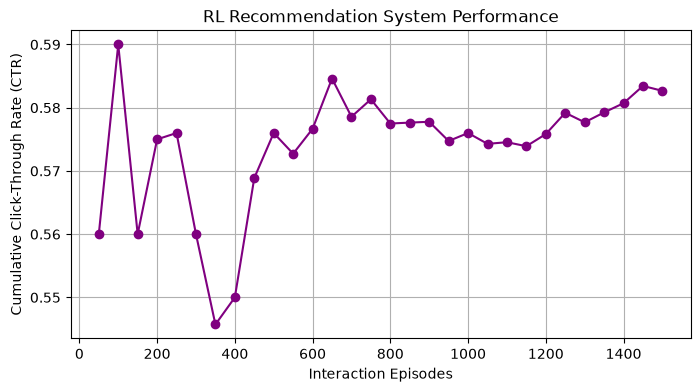

In [3]:
# RL Agent (Simplified DQN acting as a Contextual Bandit)
class RecSysNetwork(nn.Module):
    def __init__(self, context_dim, num_items):
        super(RecSysNetwork, self).__init__()
        self.fc1 = nn.Linear(context_dim, 32)
        self.fc2 = nn.Linear(32, num_items)

    def forward(self, context):
        x = torch.relu(self.fc1(context))
        return self.fc2(x)  # Outputs estimated Q-value (expected reward) for each item


def train_recsys(
    episodes=1500, epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.995
):
    env = ContextualRecSysEnv(num_items=10, context_dim=3)
    net = RecSysNetwork(context_dim=3, num_items=10)
    optimizer = optim.Adam(net.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    epsilon = epsilon_start
    rewards_history = []
    ctr_history = []  # Click-Through Rate

    cumulative_clicks = 0

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        state_tensor = torch.FloatTensor(state).unsqueeze(0)

        # Epsilon-greedy action selection (Exploration vs Exploitation)
        if np.random.rand() < epsilon:
            action = int(env.action_space.sample())
        else:
            with torch.no_grad():
                q_values = net(state_tensor)
            action = int(q_values.argmax().item())

        _, reward, _, _, _ = env.step(action)
        reward_float = float(reward)
        cumulative_clicks += reward_float

        # Update Network
        optimizer.zero_grad()
        q_values = net(state_tensor)
        target_q_values = q_values.clone()
        target_q_values[0][action] = reward_float  # Immediate reward target

        loss = loss_fn(q_values, target_q_values)
        loss.backward()
        optimizer.step()

        # Decay epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # Record metrics
        rewards_history.append(reward_float)
        if ep % 50 == 0:
            ctr = cumulative_clicks / ep
            ctr_history.append(ctr)

    env.close()
    return ctr_history


print("Training RL Recommendation Engine...")
ctr_results = train_recsys()

# Visualize Click-Through Rate (CTR) Improvement
plt.figure(figsize=(8, 4))
plt.plot(range(50, 1501, 50), ctr_results, color="purple", marker="o")
plt.title("RL Recommendation System Performance")
plt.xlabel("Interaction Episodes")
plt.ylabel("Cumulative Click-Through Rate (CTR)")
plt.grid(True)
plt.show()

## Key Questions

### 1. How can recommendation be modeled as an RL problem?
A recommendation system can be mapped to the standard RL framework where:
* **Agent:** The recommendation engine algorithm.
* **Environment:** The user (or the overall user base) interacting with the platform.
* **Objective:** The agent learns a policy to maximize the cumulative reward (long-term user engagement or lifetime value) through trial-and-error interactions.

### 2. What represents states and actions?
* **State ($S$):** The current context of the user. This includes historical interactions (watch history, past purchases), user demographics, and dynamic contextual features (time of day, device type, current location).
* **Action ($A$):** The specific item or list of items (movies, products, songs) selected by the agent to display to the user.

### 3. How is user feedback converted into rewards?
User feedback is translated into scalar reward signals ($R$):
* **Positive Rewards:** Explicit positive actions (e.g., $+1$ for a click, $+5$ for completing a video/making a purchase, $+2$ for adding to a watchlist).
* **Negative/Zero Rewards:** Implicit negative signals (e.g., $0$ for ignoring a recommendation, $-1$ for skipping rapidly or clicking "not interested").

### 4. How does RL improve long-term user engagement?
Traditional machine learning (like supervised classification) optimizes for immediate, short-term metrics (predicting if a user will click *right now*). This often leads to recommending "clickbait" or pigeonholing users into narrow content bubbles. RL optimizes for the sum of future discounted rewards ($G_t$). It strategically balances **exploitation** (showing known favorite genres) with **exploration** (introducing new genres) to keep the user discovering novel content, thereby extending their long-term retention and lifetime engagement.

---

## Supplementary Problems Analysis

### 1. Simulate user behavior
In this implementation, user behavior is simulated using a Custom Gymnasium Environment. The environment models hidden user preferences as embeddings. When an item is recommended (the action), the environment computes the dot product of the user's current context state and the item's embedding, applies a sigmoid function, and introduces Gaussian noise to output a probabilistic binary reward (click or no click).

### 2. Compare RL and Collaborative Filtering
* **Collaborative Filtering (CF):** A static approach that recommends items by finding similarities in a user-item interaction matrix. It suffers from the "cold start" problem (new users/items lack data) and cannot adapt sequentially to shifting user interests in real-time.
* **Reinforcement Learning (RL):** A dynamic, sequential approach. It can handle cold starts effectively through exploration (e.g., $\epsilon$-greedy strategies) and continuously updates its policy to adapt to the user's evolving context and immediate feedback.

### 3. Implement contextual recommendations
Contextual recommendations are implemented by defining the observation space as a continuous vector representing contextual features (e.g., time, mood). The Deep Q-Network ingests this context state and maps it directly to expected Q-values for each item, ensuring that the recommendation policy changes dynamically as the context changes, even for the exact same user.